In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ***Data load***

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rhythmghai/300k-student-performance-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 37.6M/37.6M [00:02<00:00, 15.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rhythmghai/300k-student-performance-prediction-dataset/versions/1


In [3]:
import os
print(os.listdir(path))
file_path = os.path.join(path, "student_performance_prediction_dataset-2.csv")
df = pd.read_csv(file_path)

['student_performance_prediction_dataset-2.csv']


In [4]:
df

,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,...,4.018412,Medium,Master,Yes,Mobile,Private,Coding Club,59.248749,D,Pass
1,2,18,Male,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,...,3.268642,Medium,Master,Yes,Laptop,Public,NaN,58.595595,D,Pass
2,3,19,Female,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,...,2.327293,Low,High School,Yes,Tablet,Private,Music,85.855289,A,Pass
3,4,21,Female,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,...,1.163367,Medium,Bachelor,Yes,Laptop,Public,Debate,42.117503,F,Fail
4,5,17,Male,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,...,0.411183,High,High School,Yes,Laptop,Private,Debate,62.870474,C,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,299996,20,Female,4.997969,74.093222,7.440359,52.347483,7.919553,6.528064,1.362207,...,4.708792,Medium,PhD,Yes,Mobile,Private,Arts,48.932617,F,Fail
299996,299997,17,Female,4.046644,90.982332,8.604581,83.542563,7.634545,4.677627,1.657900,...,2.797866,High,High School,Yes,Mobile,Public,Music,54.907427,D,Pass
299997,299998,16,Male,3.270361,62.681191,7.630534,72.803779,8.405001,2.453354,0.505174,...,3.264763,Medium,High School,Yes,Laptop,Public,Sports,30.199483,F,Fail
299998,299999,17,Female,1.907116,95.109287,6.341972,63.691808,9.025269,7.843200,0.000000,...,3.611083,Medium,Bachelor,Yes,NaN,Public,Music,65.075466,C,Pass


# ***Complete EDA***

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   student_id             300000 non-null  int64  
 1   age                    300000 non-null  int64  
 2   gender                 300000 non-null  object 
 3   study_hours            300000 non-null  float64
 4   attendance             300000 non-null  float64
 5   sleep_hours            300000 non-null  float64
 6   previous_grade         300000 non-null  float64
 7   assignments_completed  300000 non-null  float64
 8   practice_tests_taken   300000 non-null  float64
 9   group_study_hours      300000 non-null  float64
 10  notes_quality_score    300000 non-null  float64
 11  time_management_score  300000 non-null  float64
 12  motivation_level       300000 non-null  float64
 13  mental_health_score    300000 non-null  float64
 14  screen_time            300000 non-nu

In [6]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours,0
attendance,0
sleep_hours,0
previous_grade,0
assignments_completed,0
practice_tests_taken,0
group_study_hours,0


In [7]:
df.device_type.unique()

array(['Mobile', 'Laptop', 'Tablet', nan], dtype=object)

In [8]:
df.extracurriculars.unique()

array(['Coding Club', nan, 'Music', 'Debate', 'Sports', 'Arts'],
      dtype=object)

In [9]:
df.grade_category.unique()

array(['D', 'A', 'F', 'C', 'B', 'A+', nan], dtype=object)

In [10]:
df["device_type"] = df["device_type"].fillna("Unknown")
df["extracurriculars"] = df["extracurriculars"].fillna("Unknown")

In [11]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours,0
attendance,0
sleep_hours,0
previous_grade,0
assignments_completed,0
practice_tests_taken,0
group_study_hours,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

,0
student_id,int64
age,int64
gender,object
study_hours,float64
attendance,float64
sleep_hours,float64
previous_grade,float64
assignments_completed,float64
practice_tests_taken,float64
group_study_hours,float64


In [14]:
print(df[["final_grade", "grade_category", "pass_fail"]].head(20))

    final_grade grade_category pass_fail
0     59.248749              D      Pass
1     58.595595              D      Pass
2     85.855289              A      Pass
3     42.117503              F      Fail
4     62.870474              C      Pass
5     46.459666              F      Fail
6     56.019693              D      Pass
7     77.024409              B      Pass
8     55.377038              D      Pass
9     56.522627              D      Pass
10    88.802124              A      Pass
11    38.044512              F      Fail
12    46.395589              F      Fail
13    70.993070              B      Pass
14    60.302120              C      Pass
15    49.612850              F      Fail
16    62.135403              C      Pass
17    58.786914              D      Pass
18    57.734471              D      Pass
19    78.117945              B      Pass


In [15]:
df.describe()

,student_id,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,final_grade
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,150000.500000,17.999070,4.503062,84.699395,6.991431,69.840184,7.836044,4.017508,1.529057,6.946017,6.464472,6.945851,6.984210,4.018094,2.530258,53.089206
std,86602.684716,1.999235,1.978513,9.419450,1.463070,14.683157,1.732474,1.956444,0.941525,1.885193,1.925801,1.886246,1.471193,1.958596,1.435742,12.225161
min,1.000000,15.000000,0.000000,40.000000,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,75000.750000,16.000000,3.143566,78.241008,5.992666,59.870863,6.654817,2.655243,0.826462,5.653740,5.138654,5.655885,5.982593,2.650836,1.491633,44.867737
50%,150000.500000,18.000000,4.498272,84.990371,6.999011,69.955736,8.000829,4.001981,1.499206,7.011212,6.493222,7.005390,6.992543,3.997134,2.498493,53.167495
75%,225000.250000,20.000000,5.843646,91.732244,8.013284,80.102857,9.357154,5.349494,2.172680,8.356150,7.845919,8.356416,8.010331,5.350158,3.513496,61.379373
max,300000.000000,21.000000,12.000000,100.000000,10.000000,100.000000,10.000000,10.000000,5.840593,10.000000,10.000000,10.000000,10.000000,12.000000,8.000000,100.000000


In [16]:
df.corr(numeric_only=True)["final_grade"].sort_values(ascending=False)

,final_grade
final_grade,1.000000
study_hours,0.430957
previous_grade,0.393373
time_management_score,0.312778
motivation_level,0.306361
assignments_completed,0.282054
practice_tests_taken,0.213146
attendance,0.204748
notes_quality_score,0.201487
mental_health_score,0.159313


# **Encodeing**

In [17]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].unique())


gender:
['Male' 'Female' 'Other']

family_income:
['Medium' 'Low' 'High']

parent_education:
['Master' 'High School' 'Bachelor' 'PhD']

internet_access:
['Yes' 'No']

device_type:
['Mobile' 'Laptop' 'Tablet' 'Unknown']

school_type:
['Private' 'Public']

extracurriculars:
['Coding Club' 'Unknown' 'Music' 'Debate' 'Sports' 'Arts']

grade_category:
['D' 'A' 'F' 'C' 'B' 'A+' nan]

pass_fail:
['Pass' 'Fail']


In [18]:
df = pd.get_dummies(
    df,
    columns=[
        "gender",
        "device_type",
        "school_type",
        "extracurriculars"
    ],
    dtype=int
)

In [19]:
df["family_income"] = df["family_income"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

In [20]:
df["parent_education"] = df["parent_education"].map({
    "High School": 0,
    "Bachelor": 1,
    "Master": 2,
    "PhD": 3
})

In [21]:
df["internet_access"] = df["internet_access"].map({
    "No": 0,
    "Yes": 1
})

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   student_id                    300000 non-null  int64  
 1   age                           300000 non-null  int64  
 2   study_hours                   300000 non-null  float64
 3   attendance                    300000 non-null  float64
 4   sleep_hours                   300000 non-null  float64
 5   previous_grade                300000 non-null  float64
 6   assignments_completed         300000 non-null  float64
 7   practice_tests_taken          300000 non-null  float64
 8   group_study_hours             300000 non-null  float64
 9   notes_quality_score           300000 non-null  float64
 10  time_management_score         300000 non-null  float64
 11  motivation_level              300000 non-null  float64
 12  mental_health_score           300000 non-nul

In [23]:
y = df["final_grade"]

X = df.drop(columns=[
    "student_id",
    "final_grade",
    "grade_category",
    "pass_fail"
])

In [25]:
y.shape

(300000,)

In [26]:
X.shape

(300000, 32)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(240000, 32)
(60000, 32)
(240000,)
(60000,)


In [29]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

print(numeric_cols)
print("Total numerical features:", len(numeric_cols))

Index(['age', 'study_hours', 'attendance', 'sleep_hours', 'previous_grade',
       'assignments_completed', 'practice_tests_taken', 'group_study_hours',
       'notes_quality_score', 'time_management_score', 'motivation_level',
       'mental_health_score', 'screen_time', 'social_media_hours',
       'family_income', 'parent_education', 'internet_access', 'gender_Female',
       'gender_Male', 'gender_Other', 'device_type_Laptop',
       'device_type_Mobile', 'device_type_Tablet', 'device_type_Unknown',
       'school_type_Private', 'school_type_Public', 'extracurriculars_Arts',
       'extracurriculars_Coding Club', 'extracurriculars_Debate',
       'extracurriculars_Music', 'extracurriculars_Sports',
       'extracurriculars_Unknown'],
      dtype='object')
Total numerical features: 32


# ***outlier detection***

In [30]:
print(X_train["study_hours"].describe())

count    240000.000000
mean          4.505630
std           1.981210
min           0.000000
25%           3.145323
50%           4.501813
75%           5.851213
max          12.000000
Name: study_hours, dtype: float64


In [31]:
Q1 = X_train["study_hours"].quantile(0.25)
Q3 = X_train["study_hours"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 3.1453230269151824
Q3: 5.851213092488976
IQR: 2.7058900655737936
Lower Bound: -0.9135120714455081
Upper Bound: 9.910048190849666


In [32]:
outliers = X_train[
    (X_train["study_hours"] < lower_bound) |
    (X_train["study_hours"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 824


In [34]:
outlier_counts = {}

for col in numeric_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((X_train[col] < lower) | (X_train[col] > upper)).sum()

    outlier_counts[col] = count

print(outlier_counts)

{'age': np.int64(0), 'study_hours': np.int64(824), 'attendance': np.int64(844), 'sleep_hours': np.int64(0), 'previous_grade': np.int64(805), 'assignments_completed': np.int64(857), 'practice_tests_taken': np.int64(852), 'group_study_hours': np.int64(835), 'notes_quality_score': np.int64(889), 'time_management_score': np.int64(810), 'motivation_level': np.int64(828), 'mental_health_score': np.int64(850), 'screen_time': np.int64(815), 'social_media_hours': np.int64(841), 'family_income': np.int64(0), 'parent_education': np.int64(11719), 'internet_access': np.int64(35974), 'gender_Female': np.int64(0), 'gender_Male': np.int64(0), 'gender_Other': np.int64(9632), 'device_type_Laptop': np.int64(0), 'device_type_Mobile': np.int64(0), 'device_type_Tablet': np.int64(23813), 'device_type_Unknown': np.int64(12073), 'school_type_Private': np.int64(0), 'school_type_Public': np.int64(0), 'extracurriculars_Arts': np.int64(40189), 'extracurriculars_Coding Club': np.int64(40070), 'extracurriculars_Deba

# ***Feature Scaling***

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(240000, 32)
(60000, 32)


# ***ANN Model***

In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [38]:
model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(32,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [42]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 79.5566 - mae: 5.3879 - val_loss: 27.7488 - val_mae: 4.2018
Epoch 2/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - loss: 26.8404 - mae: 4.1347 - val_loss: 26.5489 - val_mae: 4.1120
Epoch 3/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 26.1320 - mae: 4.0789 - val_loss: 26.1900 - val_mae: 4.0825
Epoch 4/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 25.8615 - mae: 4.0580 - val_loss: 25.9372 - val_mae: 4.0616
Epoch 5/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 25.7502 - mae: 4.0498 - val_loss: 26.0546 - val_mae: 4.0693
Epoch 6/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 25.6877 - mae: 4.0435 - val_loss: 26.0821 - val_mae: 4.0733
Epoch 7/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 25.6195 - mae: 4.0402 - val_loss: 25.8720 - val_mae: 4.0578
Epoch 8/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 25.5831 - mae: 4.0359 - val_loss: 26.0455 - val_mae: 4.0711
Epoch 9/20
6000/6000 

In [43]:
print(history.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


In [44]:
for epoch in range(20):
    print(
        f"Epoch {epoch + 1}: "
        f"Loss = {history.history['loss'][epoch]:.4f}, "
        f"MAE = {history.history['mae'][epoch]:.4f}, "
        f"Val Loss = {history.history['val_loss'][epoch]:.4f}, "
        f"Val MAE = {history.history['val_mae'][epoch]:.4f}"
    )

Epoch 1: Loss = 79.5566, MAE = 5.3879, Val Loss = 27.7488, Val MAE = 4.2018
Epoch 2: Loss = 26.8404, MAE = 4.1347, Val Loss = 26.5489, Val MAE = 4.1120
Epoch 3: Loss = 26.1320, MAE = 4.0789, Val Loss = 26.1900, Val MAE = 4.0825
Epoch 4: Loss = 25.8615, MAE = 4.0580, Val Loss = 25.9372, Val MAE = 4.0616
Epoch 5: Loss = 25.7502, MAE = 4.0498, Val Loss = 26.0546, Val MAE = 4.0693
Epoch 6: Loss = 25.6877, MAE = 4.0435, Val Loss = 26.0821, Val MAE = 4.0733
Epoch 7: Loss = 25.6195, MAE = 4.0402, Val Loss = 25.8720, Val MAE = 4.0578
Epoch 8: Loss = 25.5831, MAE = 4.0359, Val Loss = 26.0455, Val MAE = 4.0711
Epoch 9: Loss = 25.5400, MAE = 4.0327, Val Loss = 26.0159, Val MAE = 4.0695
Epoch 10: Loss = 25.5103, MAE = 4.0301, Val Loss = 26.1849, Val MAE = 4.0781
Epoch 11: Loss = 25.4812, MAE = 4.0276, Val Loss = 26.0965, Val MAE = 4.0748
Epoch 12: Loss = 25.4690, MAE = 4.0286, Val Loss = 25.8923, Val MAE = 4.0606
Epoch 13: Loss = 25.4295, MAE = 4.0233, Val Loss = 25.9819, Val MAE = 4.0681
Epoch 14

# ***Training Loss and Validation Loss Graph***

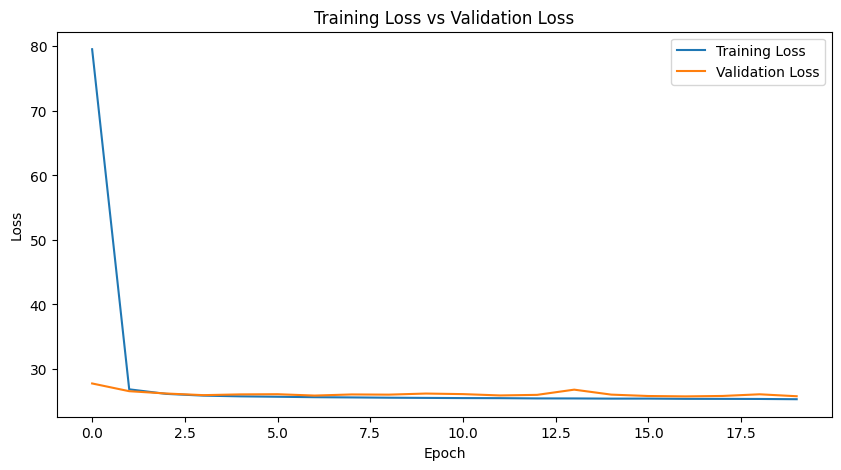

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()

plt.show()

# ***Conclusion:***
   The training and validation loss decreased rapidly during the initial epochs. After a few epochs, the loss curves became relatively stable. The training and validation losses remained close to each other, indicating that there is no strong evidence of overfitting in the current model

In [46]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:10])

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
[[68.092094]
 [67.71159 ]
 [66.72387 ]
 [70.27928 ]
 [57.038464]
 [44.521534]
 [57.879894]
 [54.451946]
 [62.315147]
 [70.07655 ]]


In [48]:
y_pred = y_pred.flatten()

In [49]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

print(comparison)

      Actual  Predicted
0  71.326607  68.092094
1  74.775774  67.711594
2  66.361362  66.723869
3  71.182141  70.279282
4  60.550851  57.038464
5  44.119818  44.521534
6  51.569524  57.879894
7  59.987718  54.451946
8  63.416381  62.315147
9  68.868046  70.076553


In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)

print("Test MAE:", test_mae)
print("Test MSE:", test_mse)
print("Test RMSE:", test_rmse)

Test MAE: 4.049507094691229
Test MSE: 25.709290120419237
Test RMSE: 5.070432932247426


# ***Activation Function Comparison***

In [51]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model_tanh = Sequential([
    Dense(64, activation="tanh", input_shape=(32,)),
    Dense(32, activation="tanh"),
    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model_tanh.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model_tanh.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [56]:
history_tanh = model_tanh.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 243.8350 - mae: 9.7706 - val_loss: 27.4272 - val_mae: 4.1545
Epoch 2/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 26.0408 - mae: 4.0653 - val_loss: 26.0595 - val_mae: 4.0736
Epoch 3/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 25.5415 - mae: 4.0315 - val_loss: 26.0136 - val_mae: 4.0689
Epoch 4/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 25.4165 - mae: 4.0223 - val_loss: 25.9436 - val_mae: 4.0631
Epoch 5/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 25.3749 - mae: 4.0185 - val_loss: 25.7281 - val_mae: 4.0439
Epoch 6/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 25.3089 - mae: 4.0151 - val_loss: 25.7647 - val_mae: 4.0490
Epoch 7/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 25.2652 - mae: 4.0097 - val_loss: 25.7566 - val_mae: 4.0523
Epoch 8/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 25.2297 - mae: 4.0080 - val_loss: 25.7605 - val_mae: 4.0502
Epoch 9/20
6000/6

In [63]:
print(history_tanh.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


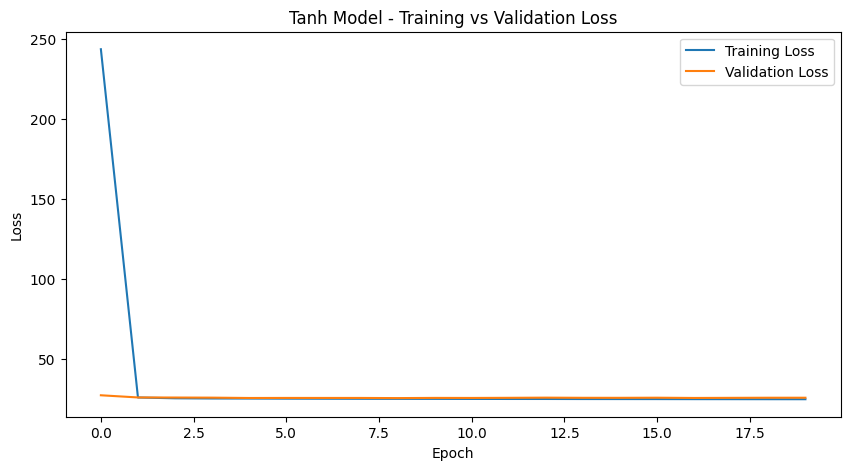

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history_tanh.history["loss"], label="Training Loss")
plt.plot(history_tanh.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Tanh Model - Training vs Validation Loss")
plt.legend()

plt.show()

In [59]:
y_pred_tanh = model_tanh.predict(X_test_scaled)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step


In [60]:
y_pred_tanh = y_pred_tanh.flatten()

In [61]:
comparison_tanh = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred_tanh[:10]
})

print(comparison_tanh)

      Actual  Predicted
0  71.326607  66.215759
1  74.775774  67.388596
2  66.361362  66.801819
3  71.182141  69.155411
4  60.550851  57.201519
5  44.119818  45.317234
6  51.569524  56.675289
7  59.987718  56.305561
8  63.416381  62.429096
9  68.868046  71.826385


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

test_mae_tanh = mean_absolute_error(y_test, y_pred_tanh)
test_mse_tanh = mean_squared_error(y_test, y_pred_tanh)
test_rmse_tanh = np.sqrt(test_mse_tanh)

print("Test MAE:", test_mae_tanh)
print("Test MSE:", test_mse_tanh)
print("Test RMSE:", test_rmse_tanh)

Test MAE: 4.051899697501175
Test MSE: 25.74901788073809
Test RMSE: 5.074349010537025


# ***Sigmoid Model***

In [64]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model_sigmoid = Sequential([
    Dense(64, activation="sigmoid", input_shape=(32,)),
    Dense(32, activation="sigmoid"),
    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [66]:
.summary()model_sigmoid

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
model_sigmoid.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [68]:
history_sigmoid = model_sigmoid.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 400.5066 - mae: 13.5553 - val_loss: 30.5818 - val_mae: 4.3161
Epoch 2/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 26.6273 - mae: 4.0946 - val_loss: 25.8243 - val_mae: 4.0465
Epoch 3/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 25.3526 - mae: 4.0143 - val_loss: 25.5819 - val_mae: 4.0333
Epoch 4/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 25.1954 - mae: 4.0042 - val_loss: 25.4439 - val_mae: 4.0240
Epoch 5/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 25.1512 - mae: 4.0008 - val_loss: 25.3419 - val_mae: 4.0163
Epoch 6/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 25.1261 - mae: 3.9992 - val_loss: 25.6355 - val_mae: 4.0399
Epoch 7/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 25.0970 - mae: 3.9972 - val_loss: 25.5414 - val_mae: 4.0316
Epoch 8/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 25.0691 - mae: 3.9958 - val_loss: 25.5725 - val_mae: 4.0374
Epoch 9/20
6000/6

In [69]:
print(history_sigmoid.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


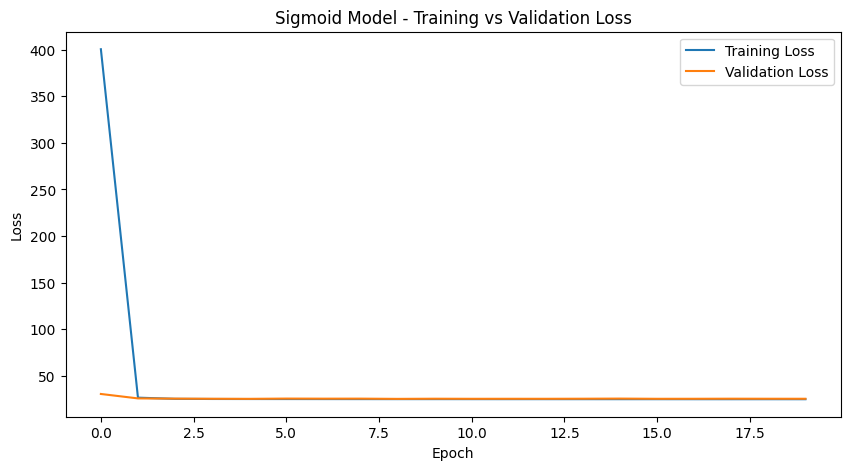

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history_sigmoid.history["loss"], label="Training Loss")
plt.plot(history_sigmoid.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sigmoid Model - Training vs Validation Loss")
plt.legend()

plt.show()

In [71]:
y_pred_sigmoid = model_sigmoid.predict(X_test_scaled)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 674us/step


In [72]:
y_pred_sigmoid = y_pred_sigmoid.flatten()

In [73]:
test_mae_sigmoid = mean_absolute_error(y_test, y_pred_sigmoid)
test_mse_sigmoid = mean_squared_error(y_test, y_pred_sigmoid)
test_rmse_sigmoid = np.sqrt(test_mse_sigmoid)

print("Sigmoid Test MAE:", test_mae_sigmoid)
print("Sigmoid Test MSE:", test_mse_sigmoid)
print("Sigmoid Test RMSE:", test_rmse_sigmoid)

Sigmoid Test MAE: 4.017199427134513
Sigmoid Test MSE: 25.29744998065771
Sigmoid Test RMSE: 5.029657044039654


# ***Sigmoid + SGD Model***

In [74]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model_sgd = Sequential([
    Dense(64, activation="sigmoid", input_shape=(32,)),
    Dense(32, activation="sigmoid"),
    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
model_sgd.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
model_sgd.compile(
    optimizer="sgd",
    loss="mse",
    metrics=["mae"]
)

In [77]:
history_sgd = model_sgd.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 28.6012 - mae: 4.1844 - val_loss: 25.9403 - val_mae: 4.0627
Epoch 2/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 25.9228 - mae: 4.0627 - val_loss: 26.3679 - val_mae: 4.0976
Epoch 3/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 25.7176 - mae: 4.0474 - val_loss: 25.9361 - val_mae: 4.0658
Epoch 4/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 25.6169 - mae: 4.0380 - val_loss: 26.1607 - val_mae: 4.0769
Epoch 5/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 25.5193 - mae: 4.0309 - val_loss: 25.7216 - val_mae: 4.0476
Epoch 6/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 25.4953 - mae: 4.0296 - val_loss: 25.9813 - val_mae: 4.0653
Epoch 7/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 25.4220 - mae: 4.0238 - val_loss: 25.8015 - val_mae: 4.0540
Epoch 8/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 25.3780 - mae: 4.0205 - val_loss: 26.6980 - val_mae: 4.1245
Epoch 9/20
6000/600

In [78]:
print(history_sgd.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


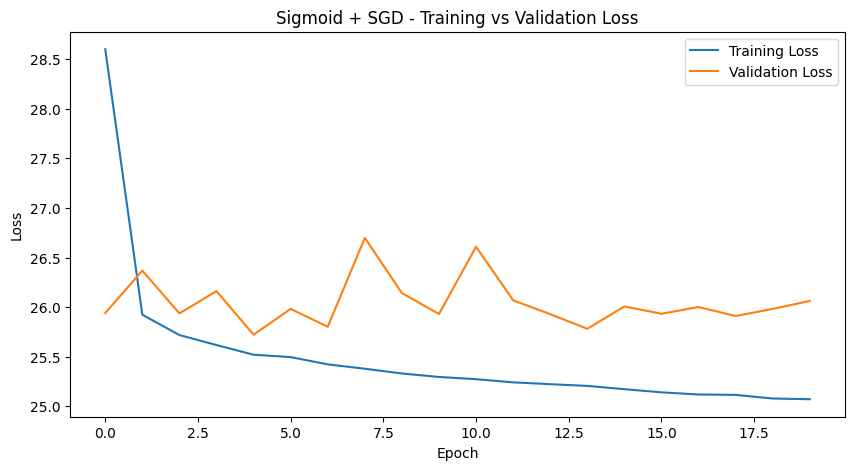

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history_sgd.history["loss"], label="Training Loss")
plt.plot(history_sgd.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sigmoid + SGD - Training vs Validation Loss")
plt.legend()

plt.show()

In [80]:
y_pred_sgd = model_sgd.predict(X_test_scaled)

y_pred_sgd = y_pred_sgd.flatten()

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step


In [81]:
comparison_sgd = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred_sgd[:10]
})

print(comparison_sgd)

      Actual  Predicted
0  71.326607  67.996521
1  74.775774  69.587044
2  66.361362  66.100761
3  71.182141  70.431503
4  60.550851  58.204449
5  44.119818  46.099442
6  51.569524  58.357349
7  59.987718  55.299198
8  63.416381  63.594147
9  68.868046  72.394150


In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

test_mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
test_mse_sgd = mean_squared_error(y_test, y_pred_sgd)
test_rmse_sgd = np.sqrt(test_mse_sgd)

print("SGD Test MAE:", test_mae_sgd)
print("SGD Test MSE:", test_mse_sgd)
print("SGD Test RMSE:", test_rmse_sgd)

SGD Test MAE: 4.06757682289214
SGD Test MSE: 25.917370257230562
SGD Test RMSE: 5.090910552860908


# ***Sigmoid + RMSprop***

In [83]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model_rmsprop = Sequential([
    Dense(64, activation="sigmoid", input_shape=(32,)),
    Dense(32, activation="sigmoid"),
    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [84]:
model_rmsprop.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model_rmsprop.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["mae"]
)

In [87]:
history_rmsprop = model_rmsprop.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 309.9938 - mae: 10.7103 - val_loss: 26.3071 - val_mae: 4.0849
Epoch 2/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 25.5899 - mae: 4.0343 - val_loss: 25.6236 - val_mae: 4.0362
Epoch 3/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 25.3523 - mae: 4.0162 - val_loss: 25.8643 - val_mae: 4.0549
Epoch 4/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 25.2905 - mae: 4.0120 - val_loss: 25.5329 - val_mae: 4.0307
Epoch 5/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 25.2327 - mae: 4.0091 - val_loss: 25.6191 - val_mae: 4.0383
Epoch 6/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 25.1992 - mae: 4.0048 - val_loss: 26.0308 - val_mae: 4.0688
Epoch 7/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 25.1786 - mae: 4.0031 - val_loss: 25.4857 - val_mae: 4.0272
Epoch 8/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 25.1525 - mae: 4.0017 - val_loss: 25.4386 - val_mae: 4.0227
Epoch 9/20
6000

In [88]:
print(history_rmsprop.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


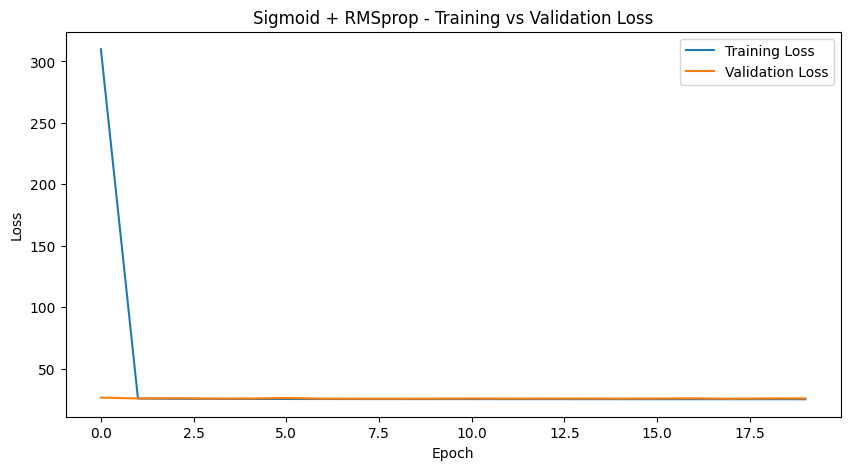

In [89]:
plt.figure(figsize=(10, 5))

plt.plot(history_rmsprop.history["loss"], label="Training Loss")
plt.plot(history_rmsprop.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sigmoid + RMSprop - Training vs Validation Loss")
plt.legend()

plt.show()

In [90]:
y_pred_rmsprop = model_rmsprop.predict(X_test_scaled)

y_pred_rmsprop = y_pred_rmsprop.flatten()

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 725us/step


In [91]:
comparison_rmsprop = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred_rmsprop[:10]
})

print(comparison_rmsprop)

      Actual  Predicted
0  71.326607  67.017029
1  74.775774  68.875404
2  66.361362  66.987015
3  71.182141  70.824295
4  60.550851  57.471069
5  44.119818  45.713749
6  51.569524  57.386703
7  59.987718  54.914024
8  63.416381  62.209412
9  68.868046  70.672585


In [92]:
test_mae_rmsprop = mean_absolute_error(y_test, y_pred_rmsprop)
test_mse_rmsprop = mean_squared_error(y_test, y_pred_rmsprop)
test_rmse_rmsprop = np.sqrt(test_mse_rmsprop)

print("RMSprop Test MAE:", test_mae_rmsprop)
print("RMSprop Test MSE:", test_mse_rmsprop)
print("RMSprop Test RMSE:", test_rmse_rmsprop)

RMSprop Test MAE: 4.0319410915874885
RMSprop Test MSE: 25.484292569987126
RMSprop Test RMSE: 5.048196962281398


# *Optimizer Comparison Table*

In [93]:
optimizer_results = pd.DataFrame({
    "Model": [
        "Sigmoid + Adam",
        "Sigmoid + SGD",
        "Sigmoid + RMSprop"
    ],
    "Activation": [
        "Sigmoid",
        "Sigmoid",
        "Sigmoid"
    ],
    "Optimizer": [
        "Adam",
        "SGD",
        "RMSprop"
    ],
    "Epochs": [
        20,
        20,
        20
    ],
    "MAE": [
        test_mae_sigmoid,
        test_mae_sgd,
        test_mae_rmsprop
    ],
    "MSE": [
        test_mse_sigmoid,
        test_mse_sgd,
        test_mse_rmsprop
    ],
    "RMSE": [
        test_rmse_sigmoid,
        test_rmse_sgd,
        test_rmse_rmsprop
    ]
})

print(optimizer_results)

               Model Activation Optimizer  Epochs       MAE        MSE  \
0     Sigmoid + Adam    Sigmoid      Adam      20  4.017199  25.297450   
1      Sigmoid + SGD    Sigmoid       SGD      20  4.067577  25.917370   
2  Sigmoid + RMSprop    Sigmoid   RMSprop      20  4.031941  25.484293   

       RMSE  
0  5.029657  
1  5.090911  
2  5.048197  


# ***Architecture 2 Create***

In [94]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model_arch2 = Sequential([
    Dense(128, activation="sigmoid", input_shape=(32,)),
    Dense(64, activation="sigmoid"),
    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [95]:
model_arch2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
model_arch2.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [97]:
history_arch2 = model_arch2.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 249.4995 - mae: 9.8056 - val_loss: 27.0241 - val_mae: 4.1287
Epoch 2/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 25.7040 - mae: 4.0391 - val_loss: 25.6512 - val_mae: 4.0398
Epoch 3/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 25.3008 - mae: 4.0128 - val_loss: 25.7051 - val_mae: 4.0439
Epoch 4/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 25.2195 - mae: 4.0075 - val_loss: 25.4565 - val_mae: 4.0256
Epoch 5/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 25.1797 - mae: 4.0042 - val_loss: 25.6933 - val_mae: 4.0436
Epoch 6/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 25.1467 - mae: 4.0022 - val_loss: 25.6244 - val_mae: 4.0378
Epoch 7/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 25.1284 - mae: 3.9998 - val_loss: 25.5215 - val_mae: 4.0307
Epoch 8/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 25.1198 - mae: 3.9994 - val_loss: 25.5189 - val_mae: 4.0298
Epoch 9/20
6000

In [98]:
print(history_arch2.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


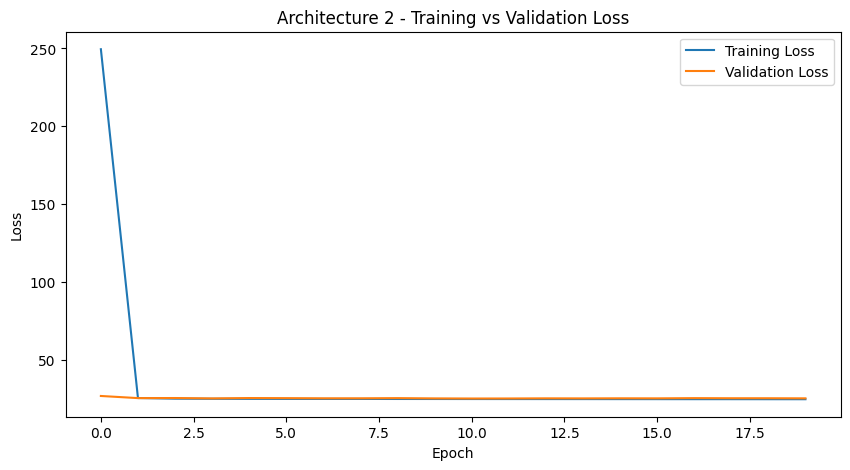

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history_arch2.history["loss"], label="Training Loss")
plt.plot(history_arch2.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Architecture 2 - Training vs Validation Loss")
plt.legend()

plt.show()

In [102]:
y_pred_arch2 = model_arch2.predict(X_test_scaled)

y_pred_arch2 = y_pred_arch2.flatten()

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [105]:
test_mae_arch2 = mean_absolute_error(y_test, y_pred_arch2)
test_mse_arch2 = mean_squared_error(y_test, y_pred_arch2)
test_rmse_arch2 = np.sqrt(test_mse_arch2)

print("Architecture 2 Test MAE:", test_mae_arch2)
print("Architecture 2 Test MSE:", test_mse_arch2)
print("Architecture 2 Test RMSE:", test_rmse_arch2)

Architecture 2 Test MAE: 4.028461402948776
Architecture 2 Test MSE: 25.437112821130796
Architecture 2 Test RMSE: 5.043521866823896


# ***Architecture 3***

In [108]:
model_arch3 = Sequential([
    Dense(128, activation="sigmoid", input_shape=(32,)),
    Dense(64, activation="sigmoid"),
    Dense(32, activation="sigmoid"),
    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [109]:
model_arch3.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,593 (57.00 KB)

 Trainable params: 14,593 (57.00 KB)

 Non-trainable params: 0 (0.00 B)

In [110]:
model_arch3.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [111]:
history_arch3 = model_arch3.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 560.0361 - mae: 18.1538 - val_loss: 60.2128 - val_mae: 5.7596
Epoch 2/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 30.1023 - mae: 4.2821 - val_loss: 26.1672 - val_mae: 4.0765
Epoch 3/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 25.5285 - mae: 4.0285 - val_loss: 26.1251 - val_mae: 4.0762
Epoch 4/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 25.3539 - mae: 4.0156 - val_loss: 25.7265 - val_mae: 4.0465
Epoch 5/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 25.2820 - mae: 4.0120 - val_loss: 25.5684 - val_mae: 4.0345
Epoch 6/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 25.2403 - mae: 4.0089 - val_loss: 25.4448 - val_mae: 4.0251
Epoch 7/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 25.1926 - mae: 4.0045 - val_loss: 25.8796 - val_mae: 4.0588
Epoch 8/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 25.1797 - mae: 4.0044 - val_loss: 25.4505 - val_mae: 4.0267
Epoch 9/20
6000

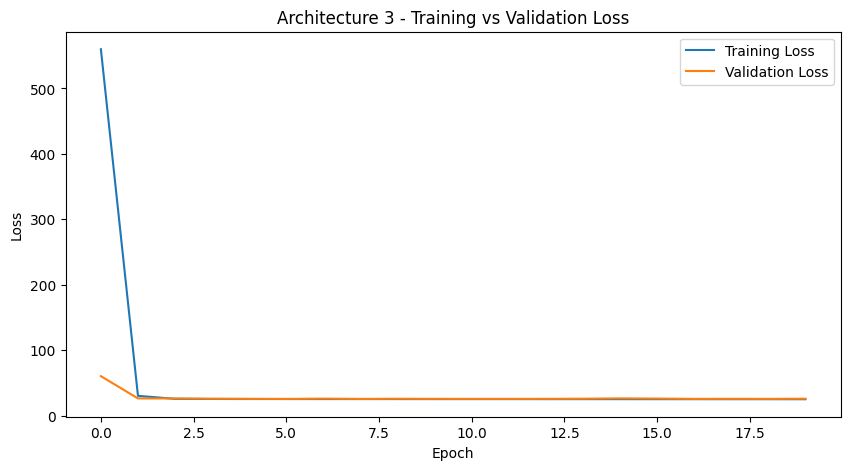

In [112]:
plt.figure(figsize=(10, 5))

plt.plot(history_arch3.history["loss"], label="Training Loss")
plt.plot(history_arch3.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Architecture 3 - Training vs Validation Loss")
plt.legend()

plt.show()

In [113]:
y_pred_arch3 = model_arch3.predict(X_test_scaled)

y_pred_arch3 = y_pred_arch3.flatten()

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 752us/step


In [114]:
test_mae_arch3 = mean_absolute_error(y_test, y_pred_arch3)

test_mse_arch3 = mean_squared_error(y_test, y_pred_arch3)

test_rmse_arch3 = np.sqrt(test_mse_arch3)

print("Architecture 3 Test MAE:", test_mae_arch3)
print("Architecture 3 Test MSE:", test_mse_arch3)
print("Architecture 3 Test RMSE:", test_rmse_arch3)

Architecture 3 Test MAE: 4.047920821832349
Architecture 3 Test MSE: 25.6773739372452
Architecture 3 Test RMSE: 5.067284671028973


In [115]:
comparison_arch3 = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred_arch3[:10]
})

print(comparison_arch3)

      Actual  Predicted
0  71.326607  67.317749
1  74.775774  68.889534
2  66.361362  66.656776
3  71.182141  70.638268
4  60.550851  57.070034
5  44.119818  45.768650
6  51.569524  57.029881
7  59.987718  55.407303
8  63.416381  62.124802
9  68.868046  70.938736


# ***architecture_results***

In [116]:
architecture_results = pd.DataFrame({
    "Architecture": [
        "32 → 64 → 32 → 1",
        "32 → 128 → 64 → 1",
        "32 → 128 → 64 → 32 → 1"
    ],
    "Hidden Layers": [2, 2, 3],
    "MAE": [
        test_mae_sigmoid,
        test_mae_arch2,
        test_mae_arch3
    ],
    "MSE": [
        test_mse_sigmoid,
        test_mse_arch2,
        test_mse_arch3
    ],
    "RMSE": [
        test_rmse_sigmoid,
        test_rmse_arch2,
        test_rmse_arch3
    ]
})

architecture_results[["MAE", "MSE", "RMSE"]] = \
    architecture_results[["MAE", "MSE", "RMSE"]].round(4)

print(architecture_results.to_string(index=False))

          Architecture  Hidden Layers    MAE     MSE   RMSE
      32 → 64 → 32 → 1              2 4.0172 25.2974 5.0297
     32 → 128 → 64 → 1              2 4.0285 25.4371 5.0435
32 → 128 → 64 → 32 → 1              3 4.0479 25.6774 5.0673


In [117]:
best_architecture = architecture_results.loc[
    architecture_results["MAE"].idxmin()
]

print("\nBest Architecture:")
print(best_architecture)


Best Architecture:
Architecture     32 → 64 → 32 → 1
Hidden Layers                   2
MAE                        4.0172
MSE                       25.2974
RMSE                       5.0297
Name: 0, dtype: object


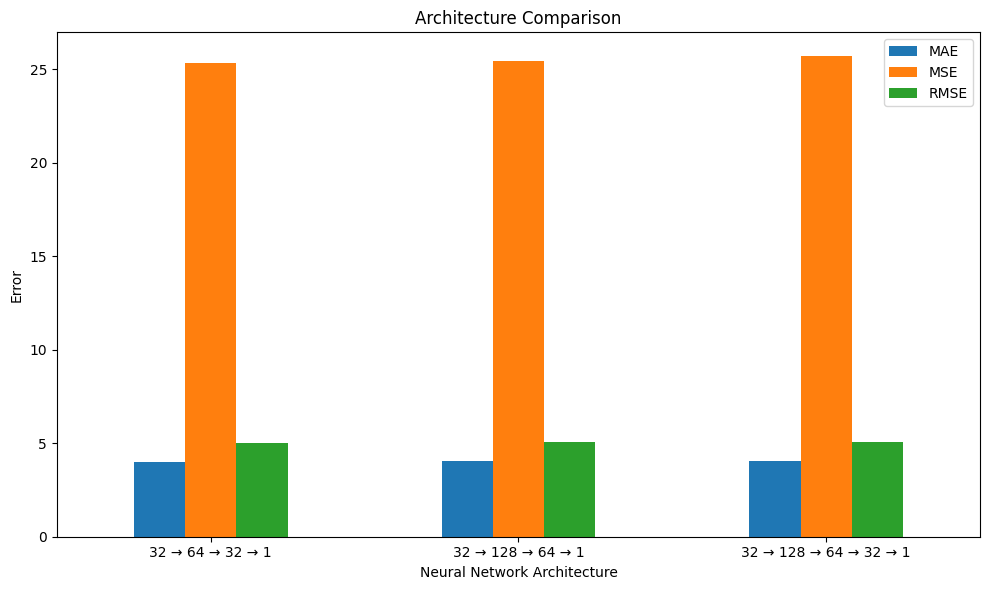

In [118]:
import matplotlib.pyplot as plt

architecture_results.plot(
    x="Architecture",
    y=["MAE", "MSE", "RMSE"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Architecture Comparison")
plt.xlabel("Neural Network Architecture")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

# ***Architecture Comparison:***
## Three neural network architectures were evaluated using MAE, MSE, and RMSE on the test dataset. The architecture with the lowest error values was considered the best-performing architecture. Based on the experimental results, [best architecture] achieved the best performance and was therefore selected as the final model.

In [119]:
print(architecture_results.to_string(index=False))

          Architecture  Hidden Layers    MAE     MSE   RMSE
      32 → 64 → 32 → 1              2 4.0172 25.2974 5.0297
     32 → 128 → 64 → 1              2 4.0285 25.4371 5.0435
32 → 128 → 64 → 32 → 1              3 4.0479 25.6774 5.0673


# ***Final Training of the Best ANN Model***

In [121]:

# Best Architecture
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("Model training completed!")

Epoch 1/50
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 45.0220 - mae: 5.1412 - val_loss: 29.7258 - val_mae: 4.3538
Epoch 2/50
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 28.0084 - mae: 4.2252 - val_loss: 26.3688 - val_mae: 4.0985
Epoch 3/50
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 26.8926 - mae: 4.1401 - val_loss: 26.9085 - val_mae: 4.1381
Epoch 4/50
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 26.5980 - mae: 4.1178 - val_loss: 25.5044 - val_mae: 4.0271
Epoch 5/50
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step - loss: 26.6186 - mae: 4.1177 - val_loss: 27.3222 - val_mae: 4.1751
Epoch 6/50
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 26.3451 - mae: 4.0972 - val_loss: 28.3926 - val_mae: 4.2536
Epoch 7/50
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 26.4539 - mae: 4.1067 - val_loss: 26.0755 - val_mae: 4.0750
Epoch 8/50
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 26.2338 - mae: 4.0892 - val_loss: 25.8750 - val_mae: 4.0582
Epoch 9/50
6000/6000

## ***Training & Validation Loss Graph***

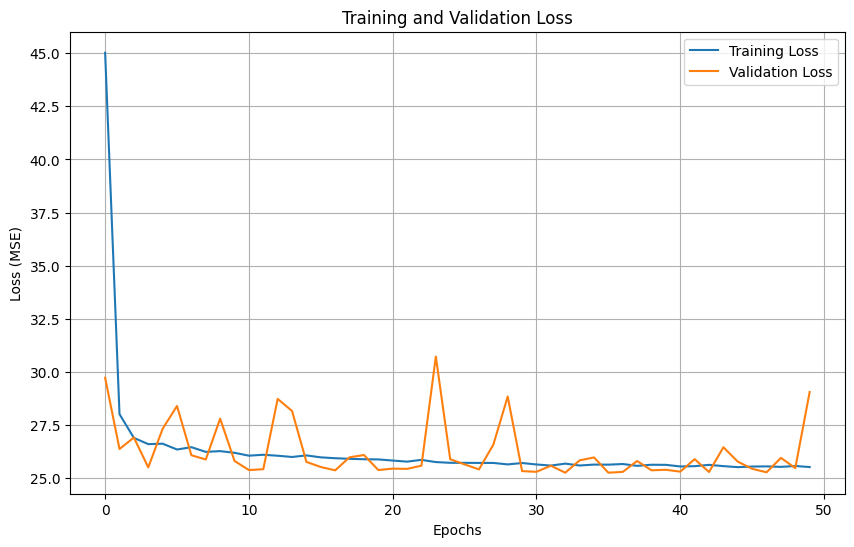

In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.show()

# ***Training & Validation MAE Graph***

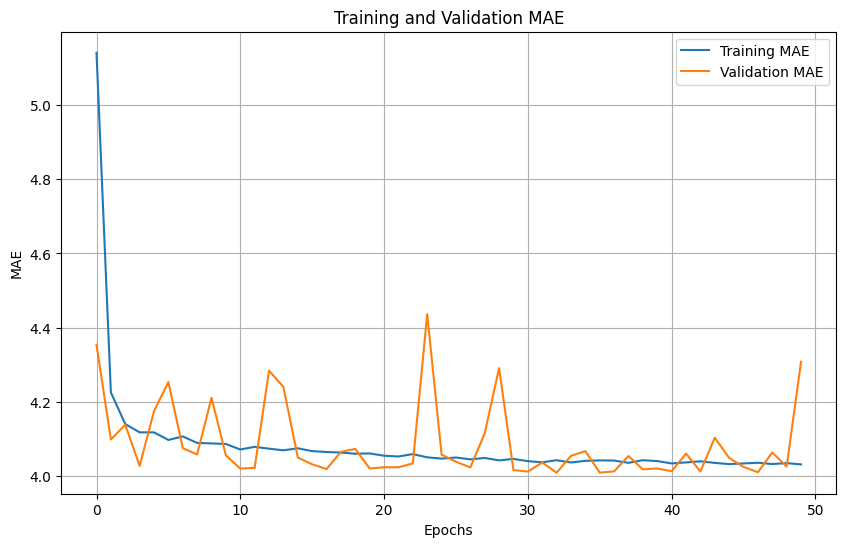

In [123]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.show()

# Predictions on Test Data

In [124]:
# Predict values for the test dataset
y_pred = model.predict(X_test, verbose=0).flatten()

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[69.08368  70.04292  68.51004  72.96921  59.11037  47.162857 59.351963
 57.016125 64.791565 72.19623 ]


# ***Calculate Final Evaluation Metrics***

In [125]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Final Model Performance")
print("-----------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Final Model Performance
-----------------------
MAE  : 4.2947
MSE  : 28.8733
RMSE : 5.3734


# ***Final Model Evaluation***

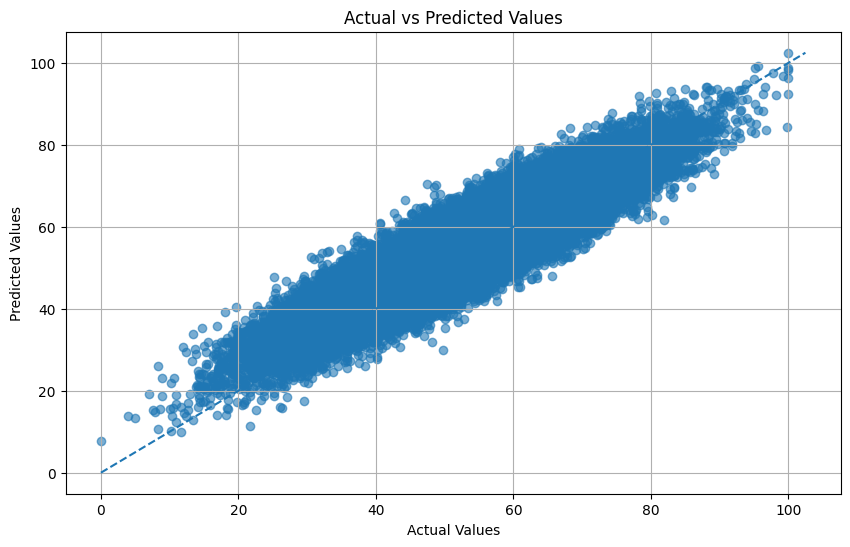

In [126]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)

plt.show()

# ***Actual vs Predicted Table***

In [127]:
comparison = pd.DataFrame({
    'Actual': np.array(y_test).flatten(),
    'Predicted': y_pred
})

print(comparison.head(20))

       Actual  Predicted
0   71.326607  69.083679
1   74.775774  70.042923
2   66.361362  68.510040
3   71.182141  72.969208
4   60.550851  59.110371
5   44.119818  47.162857
6   51.569524  59.351963
7   59.987718  57.016125
8   63.416381  64.791565
9   68.868046  72.196228
10  49.797845  51.834152
11  49.551784  49.699829
12  38.337784  42.087368
13  40.470856  46.418957
14  53.859944  63.619411
15  61.150646  62.655987
16  47.683112  48.719532
17  47.093573  47.908947
18  56.395769  55.490116
19  23.984704  25.240396


# **Final Model Performance Comparison**

In [135]:
# ============================================================
# AUTOMATIC FINAL RESULTS COMPARISON
# ============================================================

final_results = architecture_results.copy()

# Sort models from best to worst based on RMSE
final_results = final_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

# Add ranking automatically
final_results.insert(
    0,
    "Rank",
    range(1, len(final_results) + 1)
)

# Display results
print("=" * 80)
print("              AUTOMATIC FINAL MODEL COMPARISON")
print("=" * 80)

print(final_results.to_string(index=False))

# ------------------------------------------------------------
# Automatically identify best model
# ------------------------------------------------------------

best_model = final_results.iloc[0]

print("\n" + "=" * 80)
print("                    BEST MODEL")
print("=" * 80)

print(f"Architecture : {best_model['Architecture']}")
print(f"Hidden Layers: {best_model['Hidden Layers']}")
print(f"MAE          : {best_model['MAE']:.4f}")
print(f"MSE          : {best_model['MSE']:.4f}")
print(f"RMSE         : {best_model['RMSE']:.4f}")

              AUTOMATIC FINAL MODEL COMPARISON
 Rank           Architecture  Hidden Layers    MAE     MSE   RMSE
    1       32 → 64 → 32 → 1              2 4.0172 25.2974 5.0297
    2      32 → 128 → 64 → 1              2 4.0285 25.4371 5.0435
    3 32 → 128 → 64 → 32 → 1              3 4.0479 25.6774 5.0673

                    BEST MODEL
Architecture : 32 → 64 → 32 → 1
Hidden Layers: 2
MAE          : 4.0172
MSE          : 25.2974
RMSE         : 5.0297


***Results Interpretation***

The performance of the three Artificial Neural Network (ANN) architectures was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE). Since lower values of these evaluation metrics indicate better prediction performance, the architecture with the lowest error values was selected as the best-performing model.

Among the three tested architectures, the **32 → 64 → 32 → 1** architecture achieved the best overall performance, with an **MAE of 4.0172, MSE of 25.2974, and RMSE of 5.0297**. The **32 → 128 → 64 → 1** architecture produced slightly higher errors, with an MAE of 4.0285, MSE of 25.4371, and RMSE of 5.0435. The deeper **32 → 128 → 64 → 32 → 1** architecture produced the highest errors, with an MAE of 4.0479, MSE of 25.6774, and RMSE of 5.0673.

These results indicate that increasing the number of neurons or hidden layers did not improve the model's performance for this dataset. Instead, the relatively simpler **32 → 64 → 32 → 1** architecture provided the lowest prediction error. This suggests that the simpler network was sufficient to learn the underlying relationships in the data without introducing unnecessary model complexity.

The Actual vs. Predicted results also show that the predicted values are generally close to the actual values. For example, an actual value of 71.33 was predicted as 69.08, while an actual value of 74.78 was predicted as 70.04. Although some differences exist between actual and predicted values, the model is able to capture the general pattern of the target variable.

Overall, based on the evaluation metrics and prediction comparison, the **32 → 64 → 32 → 1 ANN architecture was selected as the best-performing model**. Its lower MAE, MSE, and RMSE demonstrate that it provides the most accurate predictions among the architectures tested in this experiment.


# ***[User Input and Model Prediction](`https://`)***

In [141]:
# ============================================================
# INTERACTIVE STUDENT PERFORMANCE PREDICTION
# FINAL VERSION
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. INPUT VALIDATION FUNCTIONS
# ============================================================

def get_number(prompt, min_value, max_value, integer=False):

    while True:
        try:
            value = input(prompt).strip()

            if value == "":
                print("Error: Input cannot be empty. Please try again.")
                continue

            value = float(value)

            if not np.isfinite(value):
                print("Error: Please enter a valid number.")
                continue

            if value < min_value or value > max_value:
                print(
                    f"Error: Please enter a value between "
                    f"{min_value} and {max_value}."
                )
                continue

            if integer and value != int(value):
                print("Error: Please enter a whole number.")
                continue

            return int(value) if integer else value

        except ValueError:
            print("Error: Please enter a valid number.")


def get_choice(prompt, options):

    while True:

        print("\n" + prompt)

        for i, option in enumerate(options, 1):
            print(f"  {i}. {option}")

        choice = input("Enter option number: ").strip()

        try:
            choice = int(choice)

            if 1 <= choice <= len(options):
                return options[choice - 1]

            print(
                f"Error: Please enter a number between "
                f"1 and {len(options)}."
            )

        except ValueError:
            print(
                f"Error: Please enter a number between "
                f"1 and {len(options)}."
            )


# ============================================================
# 2. USER INPUT
# ============================================================

print("\n" + "=" * 70)
print("       STUDENT PERFORMANCE PREDICTION SYSTEM")
print("=" * 70)

print("\nEnter the student's information.")
print("All inputs will be validated automatically.")


age = get_number(
    "\n1. Age (10-100 years): ",
    10, 100, True
)

study_hours = get_number(
    "\n2. Study Hours (0-24 hours per day): ",
    0, 24
)

attendance = get_number(
    "\n3. Attendance (0-100%): ",
    0, 100
)

sleep_hours = get_number(
    "\n4. Sleep Hours (0-24 hours per day): ",
    0, 24
)

previous_grade = get_number(
    "\n5. Previous Grade (0-100): ",
    0, 100
)

assignments_completed = get_number(
    "\n6. Assignments Completed (0-100): ",
    0, 100, True
)

practice_tests_taken = get_number(
    "\n7. Practice Tests Taken (0-100): ",
    0, 100, True
)

group_study_hours = get_number(
    "\n8. Group Study Hours (0-24 hours per day): ",
    0, 24
)

notes_quality_score = get_number(
    "\n9. Notes Quality Score (0-10): ",
    0, 10
)

time_management_score = get_number(
    "\n10. Time Management Score (0-10): ",
    0, 10
)

motivation_level = get_number(
    "\n11. Motivation Level (0-10): ",
    0, 10
)

mental_health_score = get_number(
    "\n12. Mental Health Score (0-10): ",
    0, 10
)

screen_time = get_number(
    "\n13. Screen Time (0-24 hours per day): ",
    0, 24
)

social_media_hours = get_number(
    "\n14. Social Media Hours (0-24 hours per day): ",
    0, 24
)


# ============================================================
# 3. CATEGORICAL INPUTS
# ============================================================

family_income = get_choice(
    "15. Family Income:",
    [
        "Low",
        "Medium",
        "High"
    ]
)

parent_education = get_choice(
    "16. Parent Education:",
    [
        "High School",
        "Bachelor",
        "Master",
        "PhD"
    ]
)

internet_access = get_choice(
    "17. Internet Access:",
    [
        "No",
        "Yes"
    ]
)

gender = get_choice(
    "18. Gender:",
    [
        "Female",
        "Male",
        "Other"
    ]
)

device_type = get_choice(
    "19. Device Type:",
    [
        "Laptop",
        "Mobile",
        "Tablet",
        "Unknown"
    ]
)

school_type = get_choice(
    "20. School Type:",
    [
        "Private",
        "Public"
    ]
)

extracurriculars = get_choice(
    "21. Extracurricular Activity:",
    [
        "Arts",
        "Coding Club",
        "Debate",
        "Music",
        "Sports",
        "Unknown"
    ]
)


# ============================================================
# 4. CREATE USER DATA
# ============================================================

user_data = pd.DataFrame({

    "age": [age],
    "study_hours": [study_hours],
    "attendance": [attendance],
    "sleep_hours": [sleep_hours],
    "previous_grade": [previous_grade],
    "assignments_completed": [assignments_completed],
    "practice_tests_taken": [practice_tests_taken],
    "group_study_hours": [group_study_hours],
    "notes_quality_score": [notes_quality_score],
    "time_management_score": [time_management_score],
    "motivation_level": [motivation_level],
    "mental_health_score": [mental_health_score],
    "screen_time": [screen_time],
    "social_media_hours": [social_media_hours],

    "family_income": [family_income],
    "parent_education": [parent_education],
    "internet_access": [internet_access],
    "gender": [gender],
    "device_type": [device_type],
    "school_type": [school_type],
    "extracurriculars": [extracurriculars]

})


# ============================================================
# 5. APPLY SAME ENCODING AS TRAINING
# ============================================================

# Family Income
user_data["family_income"] = user_data["family_income"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})


# Parent Education
user_data["parent_education"] = user_data["parent_education"].map({
    "High School": 0,
    "Bachelor": 1,
    "Master": 2,
    "PhD": 3
})


# Internet Access
user_data["internet_access"] = user_data["internet_access"].map({
    "No": 0,
    "Yes": 1
})


# One-hot encode the same categorical columns
user_data = pd.get_dummies(
    user_data,
    columns=[
        "gender",
        "device_type",
        "school_type",
        "extracurriculars"
    ],
    dtype=int
)


# ============================================================
# 6. MATCH EXACTLY WITH TRAINING FEATURES
# ============================================================

model_features = list(X_train.columns)

# Add any missing columns
for column in model_features:

    if column not in user_data.columns:
        user_data[column] = 0


# Remove unwanted columns and arrange exact same order
user_data = user_data[model_features]


# ============================================================
# 7. APPLY THE SAME STANDARD SCALER
# ============================================================

user_data_scaled = scaler.transform(user_data)


# ============================================================
# 8. FINAL INPUT CHECK
# ============================================================

if user_data_scaled.shape[1] != 32:

    raise ValueError(
        f"Model expects 32 features, but received "
        f"{user_data_scaled.shape[1]} features."
    )


# ============================================================
# 9. MAKE PREDICTION
# ============================================================

try:

    prediction = model.predict(
        user_data_scaled,
        verbose=0
    )

    prediction_value = float(
        np.asarray(prediction).reshape(-1)[0]
    )


    # --------------------------------------------------------
    # Keep prediction within logical grade range
    # --------------------------------------------------------

    prediction_value = np.clip(
        prediction_value,
        0,
        100
    )


    # ========================================================
    # 10. DISPLAY RESULT
    # ========================================================

    print("\n" + "=" * 70)
    print("                 PREDICTION RESULT")
    print("=" * 70)

    print(
        f"\nPredicted Final Grade: "
        f"{prediction_value:.2f} / 100"
    )

    print("\nPrediction completed successfully.")

    print("=" * 70)


except Exception as error:

    print("\n" + "=" * 70)
    print("                 PREDICTION ERROR")
    print("=" * 70)

    print("\nPrediction could not be completed.")
    print("Please check the model and preprocessing configuration.")

    print(f"\nTechnical details: {error}")

    print("=" * 70)


       STUDENT PERFORMANCE PREDICTION SYSTEM

Enter the student's information.
All inputs will be validated automatically.

1. Age (10-100 years): 15

2. Study Hours (0-24 hours per day): 3

3. Attendance (0-100%): 70

4. Sleep Hours (0-24 hours per day): 6

5. Previous Grade (0-100): 67

6. Assignments Completed (0-100): 58\
Error: Please enter a valid number.

6. Assignments Completed (0-100): 50

7. Practice Tests Taken (0-100): 57

8. Group Study Hours (0-24 hours per day): 3

9. Notes Quality Score (0-10): 5

10. Time Management Score (0-10): 5

11. Motivation Level (0-10): 6

12. Mental Health Score (0-10): 6

13. Screen Time (0-24 hours per day): 7

14. Social Media Hours (0-24 hours per day): 7

15. Family Income:
  1. Low
  2. Medium
  3. High
Enter option number: 3

16. Parent Education:
  1. High School
  2. Bachelor
  3. Master
  4. PhD
Enter option number: 2

17. Internet Access:
  1. No
  2. Yes
Enter option number: 2

18. Gender:
  1. Female
  2. Male
  3. Other
Enter o

In [ ]:
3